#**PROJECT: Business analysis of global e-shop**

**Dataset:** [Superstore Dataset](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

The Superstore Sales Dataset contains transaction-level data for a fictitious global retail company selling Furniture, Office Supplies, and Technology products. The dataset encompasses several years of sales records, including customer details, shipping information, product categories, sales revenue, and profit.

## Project Overview & Objective
The goal of this project is to analyze the historical sales data of a fictitious global retail company "Superstore" and translate raw data into actionable business strategy.

**Objectives:**
1. **Clean and preprocess** raw data to ensure accuracy.
2. **Engineer new features** (KPIs) such as Average Order Value (AOV), Profit Margin, and Delivery Time.
3. **Identify key trends and pain points:** Discover the most profitable product segments, highlight loss-making categories, and analyze customer purchasing behavior, and evaluate supply chain efficiency to provide strategic recommendations for the management team.

## Key Business Questions to Answer
Throughout this analysis, we will seek answers to the following strategic questions:
1. **Sales Trend:** Is the company growing financially year over year and what does the monthly revenue trend look like?
2. **Profitability:** Which product categories and subcategories are the primary profit drivers, and conversely, which specific products (SKUs) are causing the most significant financial drain?
3. **Customer  & Retention:** Who are our top-tier VIP customers, what are their purchasing profiles (Average Order Value vs. Frequency), and how loyal is our overall customer base?
4. **Geographic Performance**: Which regions represent company's strongest markets, and how do product preferences differ by region?
5. **Supply Chain Efficiency**: How consistent are our delivery times across different regions, and are there opportunities to optimize shipping for high-value clients?

## Phase 1: Data Cleaning
Real-world data is rarely ready for immediate analysis. In this phase, I load the dataset, preview the data, check for structural errors (missing values, duplicates), and correct data types.

In [185]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Color palette
VERDIGRIS = '#40B5AD'
LIGHT_PINK ='#FFB6C1'

In [186]:
# Load data
df = pd.read_csv('Superstore.csv', delimiter=",", encoding='latin1')

In [187]:
# Data Preview and Data Cleaning
print(f"Number of rows and columns: ", df.shape)  # number of Rows and Columns

print("First 3 rows:")  # show first 3 rows
display(df.head(3))

print("\nBasic information:") # show basic information
(df.info())

print(f"\nDuplicates: ", df.duplicated().sum()) # checking duplicates

print("\nMissing Values:")
display(df.isnull().sum()) # checking the NaN values
# df.isna().sum() -> same result

# Covert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

display(df[['Order Date','Ship Date']].dtypes)   # verify the data type

Number of rows and columns:  (9994, 21)
First 3 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714



Basic information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   f

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


## Phase 2: Feature Engineering
Next, I calculate new features to enhance analysis:
* **Delivery Time:** Days between order and shipping.
* **Profit Margin (%):** Profitability of each transaction.
* **Temporal Features:** Extracting **Year** and **Month** for trend analysis.

In [188]:
# Calculating new features: Delivery_Time and Profit_Margin
df['Delivery_Time'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

# Extracting Month and Year
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Month_Name'] = df['Order Date'].dt.month_name()
display(df.head(4))   # verify the results

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Delivery_Time,Profit_Margin,Order_Year,Order_Month,Order_Month_Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,16.0,2016,11,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,30.0,2016,11,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,47.0,2016,6,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-40.0,2015,10,October


In [189]:
# Basic Statistics
print("Basic Statistics Overview:")
round(df[['Sales','Quantity', 'Discount', 'Profit', 'Profit_Margin']].describe(),2)

Basic Statistics Overview:


,Sales,Quantity,Discount,Profit,Profit_Margin
count,9994.00,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66,12.03
std,623.25,2.23,0.21,234.26,46.68
min,0.44,1.00,0.00,-6599.98,-275.00
25%,17.28,2.00,0.00,1.73,7.50
50%,54.49,3.00,0.20,8.67,27.00
75%,209.94,5.00,0.20,29.36,36.25
max,22638.48,14.00,0.80,8399.98,50.00


## Phase 3:  Exploratory Data Analysis (EDA) & Data Visualization
In this section I will explore the data and identify the key trends and pain points to provide actionable recommendations for the management team.

### 3.1 Annual and Monthly Sales & Year-over-Year (YoY) Growth
Firstly, it's necessary to understand the macro-trend. *Is the company actually growing?* In order to answer this question, I will calculate total sales per year, the monthly sales trend and the percentage growth compared to the previous year.

In [190]:
# Annual Sales
sales_annual = round(df.groupby(['Order_Year'])['Sales'].sum().reset_index(), 2)

# Year-over-Year Growth
sales_annual["YoY_Growth_%"] = round(sales_annual['Sales'].pct_change()*100, 1)

sales_annual.rename(columns={'Sales': 'Total_Sales_USD', 'Order_Year': 'Year'}, inplace=True)

print("Annual Total Sales and Year-over-Year Growth Rate")
sales_annual

Annual Total Sales and Year-over-Year Growth Rate


,Year,Total_Sales_USD,YoY_Growth_%
0,2014,484247.50,NaN
1,2015,470532.51,-2.8
2,2016,609205.60,29.5
3,2017,733215.26,20.4


In [191]:
# Monthly Sales
monthly_sales = df.groupby(['Order_Year', 'Order_Month'])['Sales'].sum()

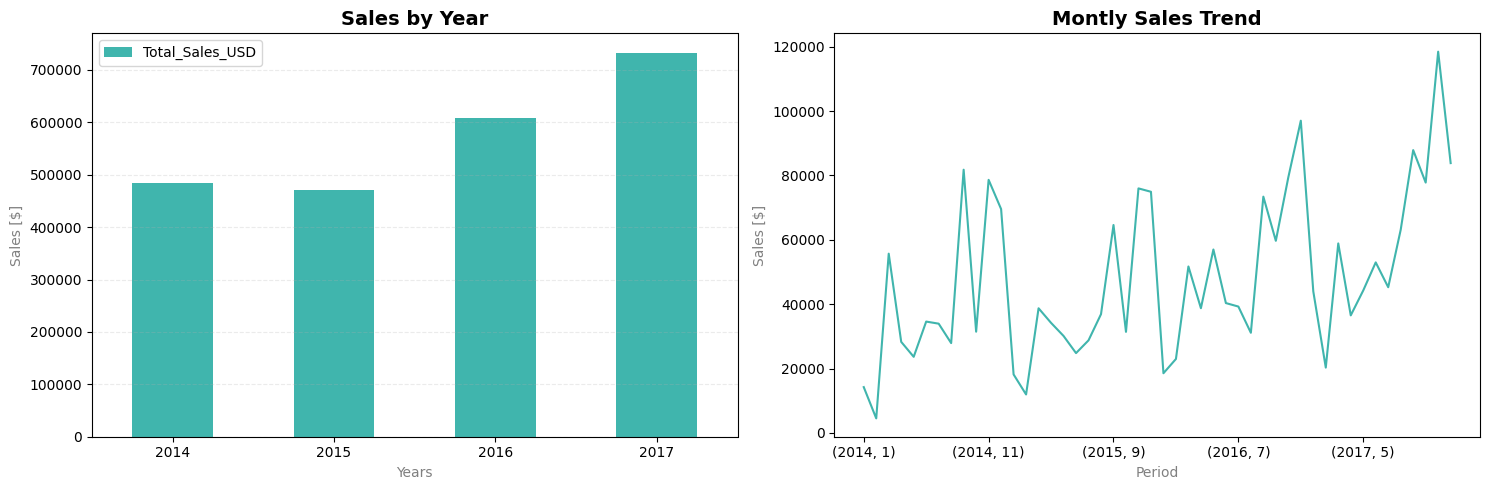

In [192]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

plt.subplot(1, 2, 1)
sales_annual.plot(kind='bar', x='Year', y='Total_Sales_USD', color=VERDIGRIS, ax=ax1)
plt.title('Sales by Year', fontsize=14, fontweight='bold')
plt.xlabel('Years', color='grey')
plt.xticks(rotation=0)
plt.ylabel('Sales [$]', color='grey')
plt.grid(axis='y', linestyle='--', alpha=0.25)


plt.subplot(1, 2, 2)
monthly_sales.plot(kind='line', color=VERDIGRIS, ax=ax2)
plt.title('Montly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Period', color='grey')
plt.ylabel('Sales [$]', color='grey')


plt.tight_layout()
plt.show()


 **Business Insight:** While sales slightly dropped by 2.8% in 2015, the company experienced a massive recovery in 2016 with a 29.5% year-over-year growth. The positive trend continued into 2017, generating over $733K in revenue.

### 3.2 Product Category Performance: A Drill-Down Analysis
Revenue does not always equal profit. In this section, I will perform a "drill-down" analysis—starting from the high-level macro view of our main product Categories, diving into the Sub-Categories, and finally pinpointing the exact Products causing financial leaks.

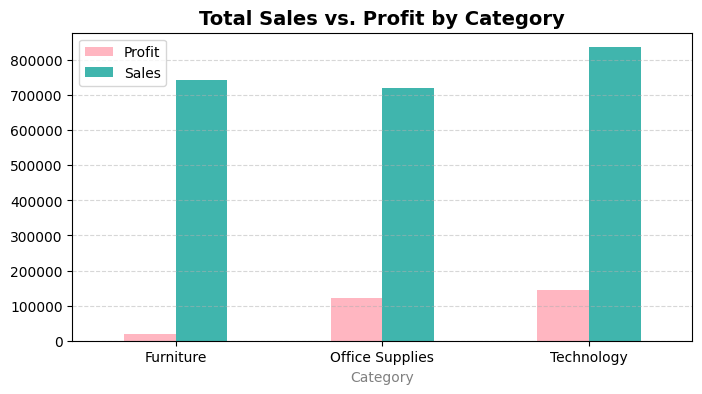


High-Level Profitability [USD]:


,Category,Profit,Sales
2,Technology,145454.95,836154.03
1,Office Supplies,122490.80,719047.03
0,Furniture,18451.27,741999.80



Average Profit Margin by Category [%]:


,Category,Profit_Margin
2,Technology,15.61
1,Office Supplies,13.80
0,Furniture,3.88


In [204]:
# 3.2.1 High-Level Category Performance
category_perf = df.groupby('Category')[['Profit', 'Sales']].sum()
avg_margin = df.groupby(['Category'])['Profit_Margin'].mean().reset_index().sort_values(by='Profit_Margin', ascending=False)

# Visualizing Sales vs Profit
category_perf.plot(kind='bar', figsize=(8, 4), color=[LIGHT_PINK, VERDIGRIS])
plt.title('Total Sales vs. Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', color='grey')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("\nHigh-Level Profitability [USD]:")
display(round(category_perf.reset_index().sort_values(['Profit'], ascending=False),2))

print("\nAverage Profit Margin by Category [%]:")
display(round(avg_margin,2))

**Insight:** Technology is company's star performer, dominating in absolute profit and boasting the highest average profit margin 15.61 %. Furniture, however, is a major concern—despite generating significant sales volume, its total profit is disproportionately low. Therefore, I need to look deeper into the Furniture category to identify which specific product Sub-Categories are bleeding Company's money.

In [194]:
# 3.2.2 Best and Worst Sub-Categories
profit_subcat = df.groupby(['Category','Sub-Category'])['Profit'].sum().reset_index().sort_values(by='Profit', ascending=False)

print("Top 3 Most Profitable Sub-Categories:")
display(profit_subcat.head(3))

print("\nTop 3 Loss-Making Sub-Categories:")
display(profit_subcat.tail(3))

Top 3 Most Profitable Sub-Categories:


,Category,Sub-Category,Profit
14,Technology,Copiers,55617.8249
16,Technology,Phones,44515.7306
13,Technology,Accessories,41936.6357



Top 3 Loss-Making Sub-Categories:


,Category,Sub-Category,Profit
12,Office Supplies,Supplies,-1189.0995
0,Furniture,Bookcases,-3472.5560
3,Furniture,Tables,-17725.4811


**Insight:** The drill-down reveals that Copiers, Phones and Accessories are driving the Technology category's success. On the other hand, the poor performance in Furniture is heavily driven by **Tables (-\$17.7K)** and **Bookcases (-$3.4K)**, which are severely bleeding money. Management should review the pricing, shipping costs, or supplier contracts fot the Furniture category.

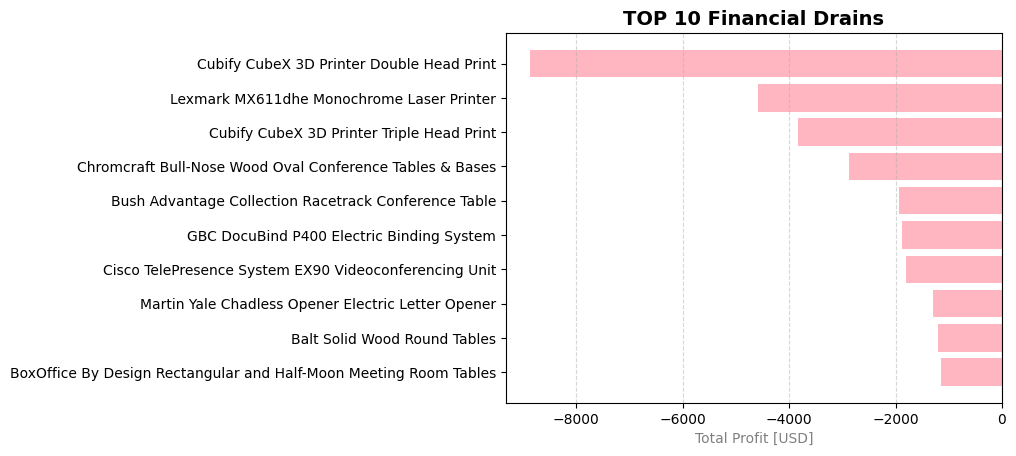


TOP 10 Products with the highest financial loss:


,Product Name,Profit
475,Cubify CubeX 3D Printer Double Head Print,-8879.97
985,Lexmark MX611dhe Monochrome Laser Printer,-4589.97
476,Cubify CubeX 3D Printer Triple Head Print,-3839.99
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.12
376,Bush Advantage Collection Racetrack Conference...,-1934.40
683,GBC DocuBind P400 Electric Binding System,-1878.17
444,Cisco TelePresence System EX90 Videoconferenci...,-1811.08
1043,Martin Yale Chadless Opener Electric Letter Op...,-1299.18
285,Balt Solid Wood Round Tables,-1201.06
364,BoxOffice By Design Rectangular and Half-Moon ...,-1148.44


In [195]:
# 3.2.3 Exact Products Causing Financial Drain
top_10_losers = df.groupby('Product Name')['Profit'].sum().reset_index().sort_values(by='Profit').head(10)

# Visualizing TOP 10 Financial Drains
plt.barh(top_10_losers['Product Name'][::-1], top_10_losers['Profit'][::-1], color=LIGHT_PINK)
plt.title('TOP 10 Financial Drains', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit [USD]', color='grey')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

print("\nTOP 10 Products with the highest financial loss:")
display(round(top_10_losers,2))

**Insight:** The financial drain in company's worst sub-categories is heavily concentrated in a few specific SKUs, most notably the "Cubify 3D Printer" and specific large tables.

**Recommendation:** Management should not drop the entire Furniture category, but rather immediately discontinue these top 10 bleeding SKUs or aggressively renegotiate their shipping costs and supplier contracts.

### 3.3 Customer Analysis: Value & Retention
Acquiring new customers is significantly more expensive than retaining existing ones. In this section, I will analyze firm's customer base to identify its most valuable VIP clients (based on Total Sales and Average Order Value) and evaluate company's overall customer retention rate.

In [196]:
# 3.3.1 VIP Customers & Average Order Value (AOV)
VIP_customers = df.groupby('Customer Name').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Orders = ('Order ID', 'nunique')
).reset_index()

VIP_customers['AOV_USD'] = round((VIP_customers['Total_Sales'] / VIP_customers['Total_Orders']), 2)

top_5_VIP = VIP_customers.sort_values(['Total_Sales'], ascending=False).head(5)   # top 5 customers

print("Top 5 Customers with the highest Sales and their Average Order Value:")
display(top_5_VIP[['Customer Name', 'Total_Sales', 'AOV_USD']])

Top 5 Customers with the highest Sales and their Average Order Value:


,Customer Name,Total_Sales,AOV_USD
686,Sean Miller,25043.050,5008.61
730,Tamara Chand,19052.218,3810.44
622,Raymond Buch,15117.339,2519.56
757,Tom Ashbrook,14595.620,3648.90
6,Adrian Barton,14473.571,1447.36


**VIP Insight & Recommendation:** Sean Miller is firm's ultimate top-tier client, leading both in total revenue (\$25K) and Average Order Value (\$5,008). However, the Top 5 reveals two distinct purchasing behaviors:
 1. **High-Ticket Buyers (B2B Profile):** Customers like Sean Miller and Tamara Chand reach high sales volumes through massive, infrequent purchases (AOV > \$3,800).
 2. **High-Frequency Buyers:** Customers like Adrian Barton reach the Top 5 through volume, making twice as many orders (10) at a lower AOV ($1,447).

 **Recommendation:** Company must segment its VIP marketing. Assign dedicated B2B account managers to its "High-Ticket" clients to supply bulk/enterprise orders. For "High-Frequency" clients like Adrian, implement a loyalty points program to keep them constantly engaged.

One-time Customers: 12
Returning Customers: 781


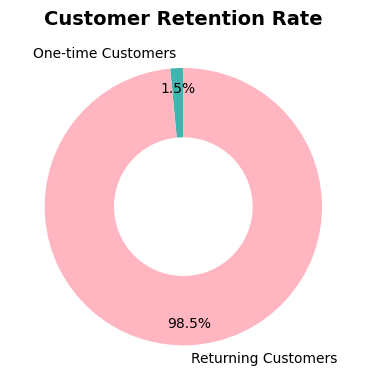

In [197]:
# 3.3.2 Customer Retention Analysis
order_frequency = df.groupby('Customer Name')['Order ID'].nunique()   # number of orders per customer

one_time = (order_frequency == 1).sum()       # customers with one order
multiple_time = (order_frequency > 1).sum()   # cusotmers with more orders

print(f"One-time Customers: {one_time}")
print(f"Returning Customers: {multiple_time}")

# Visualizing Customer Retention Rate
labels = ['One-time Customers', 'Returning Customers']
sizes = [one_time, multiple_time]
colors = [VERDIGRIS, LIGHT_PINK]

plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, pctdistance=0.85, textprops={'fontsize': 10})
plt.title('Customer Retention Rate', fontsize=14, fontweight='bold')

centre_circle = plt.Circle((0,0), 0.50, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()

**Retention Insight:** Company's retention rate is phenomenally high (98.5%), indicating immense product satisfaction and brand loyalty.

**Recommendation:** While organic retention is excellent, the marketing team should set up an automated email re-engagement campaign specifically targeting the the 12 "One-time" customers (e.g., sending a 15% discount code if they haven't purchased in 6 months) to convert them into recurring buyers.

### 3.4 Geographic Analysis: Regional Performance
Sales dynamics and product preferences vary by geography. In this final section, I will analyze which regions are company's strongest markets and use a pivot table heatmap to uncover specific regional product preferences.

,Region,Sales,Profit
3,West,725457.82,108418.45
1,East,678781.24,91522.78
0,Central,501239.89,39706.36
2,South,391721.90,46749.43


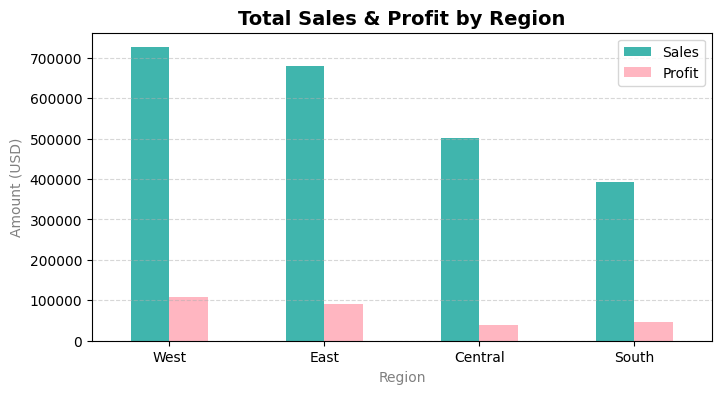

In [205]:
# 3.4.1 Overall Sales and Profit by Region
region_perf = df.groupby('Region')[['Sales', 'Profit']].sum().round(2).reset_index().sort_values(by='Sales', ascending=False)
display(region_perf)

# Visualizing Total Sales & Profit by Region
region_perf.plot(kind='bar', x='Region', figsize=(8, 4), color=[VERDIGRIS, LIGHT_PINK])
plt.title('Total Sales & Profit by Region', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.xlabel('Region', color='grey')
plt.ylabel('Amount (USD)', color='grey')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [199]:
# 3.4.2 Category Preferences by Region
cat_reg_pivot = pd.pivot_table(df,
               values='Sales',
               index='Category',
               columns='Region',
               aggfunc='sum'
          ).round(2)

print("Sales Heatmap: Category vs. Region (USD)")
display(cat_reg_pivot.style.background_gradient(cmap='Blues', axis=None).format("{:,.2f}"))

Sales Heatmap: Category vs. Region (USD)


Region,Central,East,South,West
Category,,,,
Furniture,"163,797.16","208,291.20","117,298.68","252,612.74"
Office Supplies,"167,026.42","205,516.06","125,651.31","220,853.25"
Technology,"170,416.31","264,973.98","148,771.91","251,991.83"


In [200]:
# 3.4.3 Top 10 Best-Selling Sub-Categories across Regions
top_regional_subcats = df.groupby(['Region', 'Sub-Category'])['Sales'].sum().reset_index()

print("\nTOP 10 Sub-Categories within Regions:")
display(top_regional_subcats.sort_values(by='Sales', ascending=False).head(10).round(2))


TOP 10 Sub-Categories within Regions:


,Region,Sub-Category,Sales
56,West,Chairs,101781.33
30,East,Phones,100614.98
64,West,Phones,98684.35
22,East,Chairs,96260.68
5,Central,Chairs,85230.65
67,West,Tables,84754.56
13,Central,Phones,72403.28
31,East,Storage,71612.58
65,West,Storage,70532.85
28,East,Machines,66106.17


**Insight:**
The West and East regions completely dominate company's revenue stream. The Pivot Table Heatmap clearly reveals that the biggest "cash cows" are Technology products sold in the East and West. On the other hand, the South region is lagging significantly across all categories.

**Actionable Recommendation:**
1. **Supply Chain:** Optimize warehouse inventory based on these profiles. Stock heavily on Technology and Chairs in Eastern and Western distribution centers to reduce shipping times and costs.
2. **Marketing:** Investigate why market penetration in the South is so low. Consider launching targeted, regional promotions or discounting shipping rates to stimulate demand in the Southern market.

In [201]:
# 3.4.4 Average Delivery Time by Region
delivery_stats = round(df.groupby('Region')['Delivery_Time'].mean().reset_index().sort_values(by='Delivery_Time'), 1)

print("Average Delivery Time by Region (Days):")
display(delivery_stats)

Average Delivery Time by Region (Days):


,Region,Delivery_Time
1,East,3.9
3,West,3.9
2,South,4.0
0,Central,4.1


**Insight:**
Average delivery times are highly consistent across all regions (averaging around 4 days), indicating a stable and predictable supply chain.

**Recommendation:** Since our analysis identified highly valuable B2B clients (e.g., Tamara Chand with an AOV of \$3,800+), the company should introduce an automated "Priority/Expedited Shipping" tier for all orders exceeding $1,000. This would enhance the premium customer experience without disrupting the standard logistics flow.